<a href="https://colab.research.google.com/github/its-curzon/LegoDataAnalytics/blob/main/Lego_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Lego Data - Introduction


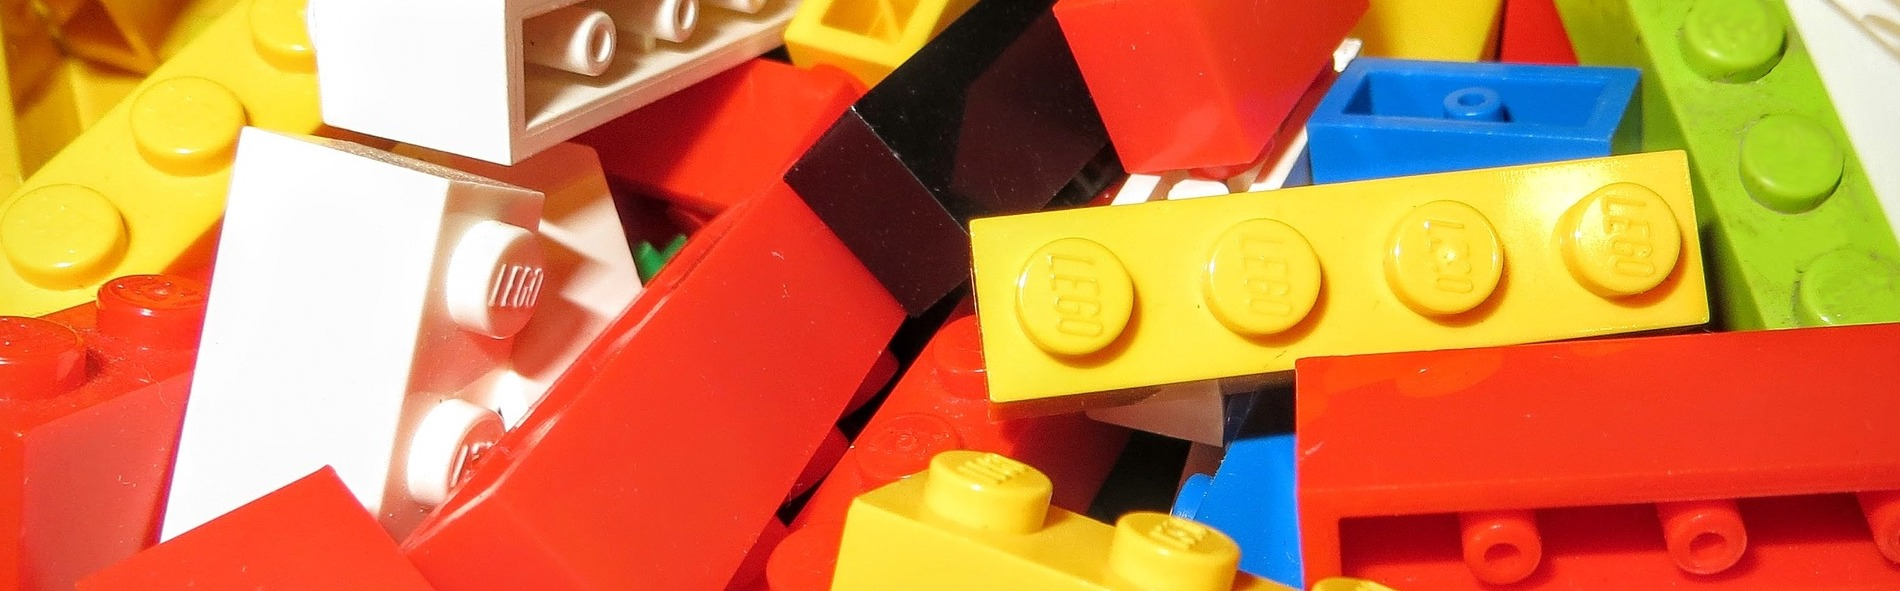

In [41]:
#this is a guided exercise I completed through coursework about Lego's dataset
#over the history of their company
#this taught me the foundations of data analysis,
#I am including it to show later in the notebook
#my skills for processing data and for noticing trends

from PIL import Image
bricks = Image.open('data/bricks.jpg')
bricks
#these are Lego. They're one of the most popular toy brands in the world.

In [1]:
#let's import pandas and read our database having to do with the color of
#Lego bricks, and check out the head, or the first 5 rows including the column
#names

import pandas as pd
colors = pd.read_csv('data/colors.csv')
colors.head()
#that gives us 'id', 'name', 'rgb', and 'is_trans' for transparent pieces

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


In [2]:
#now let's see how many unique colors are in our new database 'colors'
#we search for this by the 'name' column and the pandas .nunique() function
colors['name'].nunique()

#135 different colors!

135

In [39]:
#then, we can see how many colors are considered 'transparent'
colors.is_trans.value_counts()
#this is just one way to do this -


,count
is_trans,
f,107
t,28


In [35]:
#we can also check this way
t = colors[colors.is_trans == 't'].shape[0]
f = colors[colors.is_trans == 'f'].shape[0]

print(f'There are {t} transparent colors and {f} opaque colors.')
#this makes the data nice and translatable to people who may be
#outside the realm of data science, in my opinion.

There are 28 transparent colors and 107 opaque colors.


In [32]:
#or this way - there are quite a few ways to accomplish anything, which can make
#data analysis feel like a creative exercise, which is one of the main draws
#to this field for me.
colors.groupby('is_trans').id.count()

,id
is_trans,
f,107
t,28


<h3>Understanding LEGO Themes vs. LEGO Sets</h3>

In [4]:
#now, let's check out the 'sets' data, to learn about the types of Lego sets
#again, using pandas we read the 'sets.csv' file and look at the head.
sets = pd.read_csv('data/sets.csv')
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [5]:
#and we can look at the bottom of the list, using .tail()
#there are 15,710 sets, remembering our list starts at 0 index
sets.tail()

,set_num,name,year,theme_id,num_parts
15705,wwgp1-1,Wild West Limited Edition Gift Pack,1996,476,0
15706,XMASTREE-1,Christmas Tree,2019,410,26
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


In [6]:
#let's see what year the first set was created
#we sort the values of the 'year' column and then look at the head
sets.sort_values('year').head()

#1949 was the first year!

,set_num,name,year,theme_id,num_parts
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9534,700.2-1,Large Gift Set (ABB),1949,365,178


In [7]:
#Let's see how many they released in the first year
sets[sets['year'] == 1949]
#they released 5 sets in the first year!

,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12


In [8]:
#Now, we can look to see what set has the most number of parts
#The "Battle for Chima" set has nearly 10,000 parts!
#and the set_num is 'BIGBOX-1'. I'll say.

sets.sort_values('num_parts').tail()

,set_num,name,year,theme_id,num_parts
221,10189-1,Taj Mahal,2008,673,5922
295,10256-1,Taj Mahal,2017,673,5923
10551,71043-1,Hogwarts Castle,2018,246,6020
11183,75192-1,UCS Millennium Falcon,2017,171,7541
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987


In [66]:
#Let's look at the number of sets released by year.
#we sort our sets by the 'year' and give a count of how many there are.
#and look at the first 5 years...

sets_by_year = sets.groupby('year').count()
sets_by_year['set_num'].head()


,set_num
year,
1949,5
1950,6
1953,4
1954,14
1955,28


In [67]:
#and the last 5...this data was released sometime in 2020, hence the low set
#count for 2020 and 2021

sets_by_year['set_num'].tail()

,set_num
year,
2017,786
2018,816
2019,840
2020,674
2021,3


In [69]:
#lets drop the last 2 years, since they are incomplete
sets_by_year.drop(sets_by_year.tail(2).index, inplace=True)
sets_by_year.tail()

,set_num,name,theme_id,num_parts
year,,,,
2015,774,774,774,774
2016,757,757,757,757
2017,786,786,786,786
2018,816,816,816,816
2019,840,840,840,840


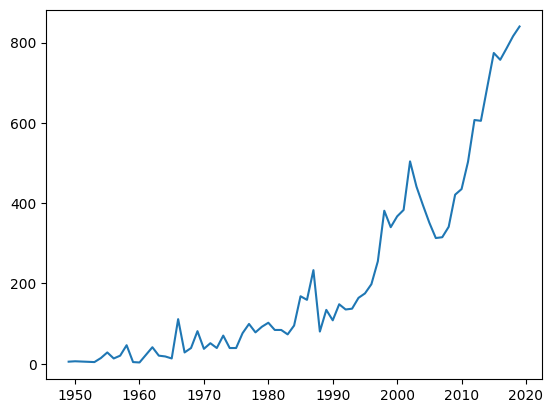

In [70]:
#Lets start some visualization. Import matplotlib and lets make a line graph
#with the set numbers v the year they were released
import matplotlib.pyplot as plt
plt.plot(sets_by_year.index, sets_by_year.set_num)

#these HUGE drop offs in the 1980s and right after the year 2000 caught my eye

### Aggregate Data with the Python .agg() Function



In [71]:
#now we can dive into the themes that they released by the year!
#this .agg({}) function took me a while to grasp -
#essentially for each of those years, it looks at the theme_id column
# and counts how many distinct (.nunique) theme IDs exist in that year.

themes_by_year = sets.groupby('year').agg({'theme_id': pd.Series.nunique})


In [73]:
#now if we change the name of the theme_id column to nr_themes for number of themes
#we can easily read how many themes released each year
themes_by_year.rename(columns={'theme_id': 'nr_themes'}, inplace=True)
themes_by_year.tail()

,nr_themes
year,
2017,89
2018,93
2019,78
2020,82
2021,1


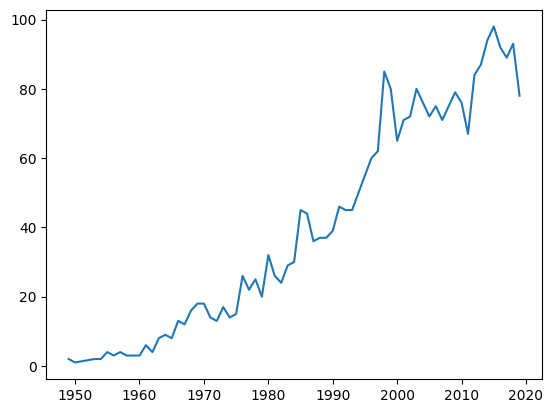

In [74]:
#but remember that 2020 and 2021 are incomplete datasets!
#instead of dropping them from the list like earlier, we
#can just ignore them on our graph by including [:-2] to
#both of our columns, to exclude the last 2 rows
plt.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2])

### Line Charts with Two Seperate Axes

Text(0, 0.5, 'Number of Themes')

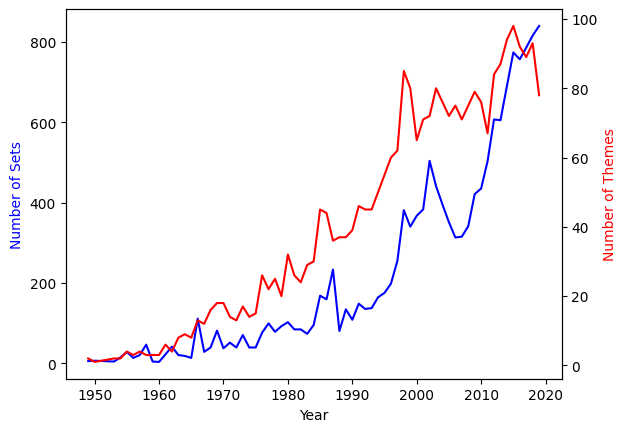

In [16]:
#we can even add a second stat to compare on a second x axis
ax1 = plt.gca()
#here we use ax2 by calling the twinx function on ax1
ax2 = ax1.twinx()
#sets by year on ax 1
ax1.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2], color="blue")
#themes by year on ax 2
ax2.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2], color="red")
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Sets', color="blue")
ax2.set_ylabel('Number of Themes', color="red")

#we see for the first time since the  mid 60s, in the mid 10s the number
#of sets exceeded the number of themes!
#I still see that massive drop off in sets in the 2000s, and it seems
#the number of themes dropped off as well, if not a couple of years later

In [17]:
#here we look at the number of parts per set, based on the year
#like earlier, we group by the year, and aggregate filter the average or mean
#of the number of parts
parts_per_set = sets.groupby('year').agg({'num_parts': pd.Series.mean})
parts_per_set.tail()

,num_parts
year,
2017,221.840967
2018,213.618873
2019,207.510714
2020,259.732938
2021,0.000000


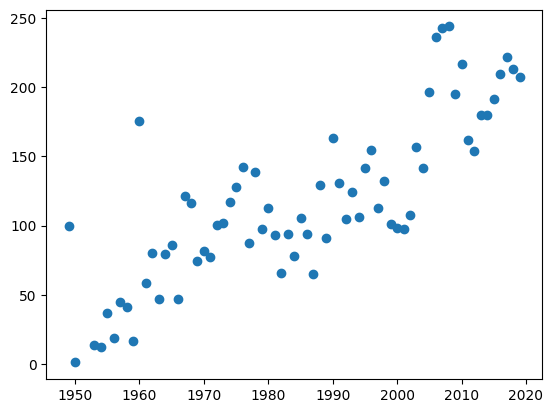

In [18]:
#lets remember to drop those last 2 rows when we go to make our
#Matplotlib scatter plot graph!
plt.scatter(parts_per_set.index[:-2], parts_per_set.num_parts[:-2])

#there has been a clear trend over time, more parts per set!

### Number of Sets per LEGO Theme

In [19]:
#now we can see what theme has the largest number of individual sets!
#lets get the count of all the theme_ids and how often they appear
set_theme_count = sets["theme_id"].value_counts()
#and show the top 5
set_theme_count[:5]

,count
theme_id,
158,753
501,656
494,398
435,356
503,329


<h2>Database Schema</h2>
<img src="https://i.imgur.com/Sg4lcjx.png" alt="Database Schema Diagram" style="width:80%;">

### Database Schemas, Foreign Keys and Merging DataFrames

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv.

**Challenge**: Explore the themes.csv. How is it structured? Search for the name 'Star Wars'. How many <code>id</code>s correspond to this name in the themes.csv? Now use these <code>id</code>s and find the corresponding the sets in the sets.csv (Hint: you'll need to look for matches in the <code>theme_id</code> column)

In [20]:
#we can see from the schema that the sets.csv column theme_ids
#has a direct like to the id column in themes.csv
#lets see how this themes csv is structured
themes = pd.read_csv('data/themes.csv')
themes.head()

,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0


In [21]:
#Let's look up a popular theme, Star Wars.
themes[themes.name == 'Star Wars']
#We have multiple theme ids assigned to Star Wars!

,id,name,parent_id
17,18,Star Wars,1.0
150,158,Star Wars,NaN
174,209,Star Wars,207.0
211,261,Star Wars,258.0


In [22]:
#I wonder why that is. Let's pick the top id '18' and see if we can
#discern what's going on here
sets[sets.theme_id == 18]

#it seems like the id '18' is assigned to character kits

,set_num,name,year,theme_id,num_parts
8786,65081-1,R2-D2 / C-3PO Droid Collectors Set,2002,18,1
12051,8000-1,Pit Droid,2000,18,223
12058,8001-1,Battle Droid,2000,18,336
12066,8002-1,Destroyer Droid,2000,18,567
12071,8007-1,C-3PO,2001,18,339
12072,8008-1,Stormtrooper,2001,18,360
12073,8009-1,R2-D2,2002,18,239
12074,8010-1,Darth Vader,2002,18,388
12081,8011-1,Jango Fett,2002,18,425
12083,8012-1,Super Battle Droid,2002,18,378


In [78]:
#The second id is 158.
sets[sets.theme_id == 158]
#here it looks like mini figures, build your own adventure kits, and promotional
#sets

,set_num,name,year,theme_id,num_parts
850,11912-1,Star Wars: Build Your Own Adventure,2016,158,73
855,11920-1,Parts for Star Wars Build Your Own Adventure: ...,2019,158,70
1717,20006-1,Clone Turbo Tank - Mini,2008,158,64
1728,20007-1,Republic Attack Cruiser - Mini,2009,158,84
1738,20009-1,AT-TE Walker - Mini,2009,158,94
...,...,...,...,...,...
15686,VP-4,Star Wars Co-Pack of 7101 7111 and 7171,2000,158,0
15689,VP-8,Star Wars Co-Pack of 7130 and 7150,2000,158,0
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52


In [23]:
#now how about the id 209?
sets[sets.theme_id == 209]
#these are Star Wars Advent Calendars, and they all share the theme_id 209

,set_num,name,year,theme_id,num_parts
11013,75023-1,Star Wars Advent Calendar 2013,2013,209,254
11046,75056-1,Star Wars Advent Calendar 2014,2014,209,273
11080,75097-1,Star Wars Advent Calendar 2015,2015,209,291
11131,75146-1,Star Wars Advent Calendar 2016,2016,209,282
11173,75184-1,Star Wars Advent Calendar 2017,2017,209,309
11206,75213-1,Star Wars Advent Calendar 2018,2018,209,307
11245,75245-1,Star Wars Advent Calendar 2019,2019,209,280
11281,75279-1,Star Wars Advent Calendar 2020,2020,209,312
12019,7958-1,Star Wars Advent Calendar 2011,2011,209,267
14352,9509-1,Star Wars Advent Calendar 2012,2012,209,235


In [24]:
#and 261 is reserved for 2 developer kits from 1999 and 200
sets[sets.theme_id == 261]

,set_num,name,year,theme_id,num_parts
14630,9748-1,Droid Developer Kit,1999,261,658
14636,9754-1,Dark Side Developers Kit,2000,261,578


### Merging (i.e., Combining) DataFrames based on a Key


In [25]:
#now we can see which "theme_id"s have the most sets made!
set_theme_count = sets["theme_id"].value_counts()
set_theme_count[:5]

#looks like 158 is the highest! That's one of our Star Wars ids!

,count
theme_id,
158,753
501,656
494,398
435,356
503,329


In [26]:
#here we can take the set_theme_count and create a new Pandas DataFrame
#using the columns 'id' which the the set_theme_count index, and 'set_count'
#which is the number of sets per id, or the values
set_theme_count = pd.DataFrame({'id':set_theme_count.index,
                                'set_count':set_theme_count.values})
set_theme_count.head()

,id,set_count
0,158,753
1,501,656
2,494,398
3,435,356
4,503,329


In [27]:
#now we can take our new set_theme_count table, and combine it with our themes
#table and 'id' is how we are going to match our rows
merged_df = pd.merge(set_theme_count, themes, on='id')
#and then we look at the top 3
merged_df[:3]

,id,set_count,name,parent_id
0,158,753,Star Wars,NaN
1,501,656,Gear,NaN
2,494,398,Friends,NaN


<BarContainer object of 10 artists>

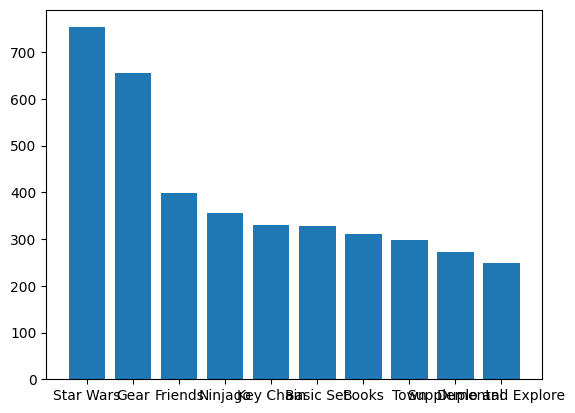

In [28]:
#now we can make a bar chart showing the top 10 themes per number of sets!
plt.bar(merged_df.name[:10], merged_df.set_count[:10])
#but, it's really hard to read this way
#so next we must format our chart

<BarContainer object of 10 artists>

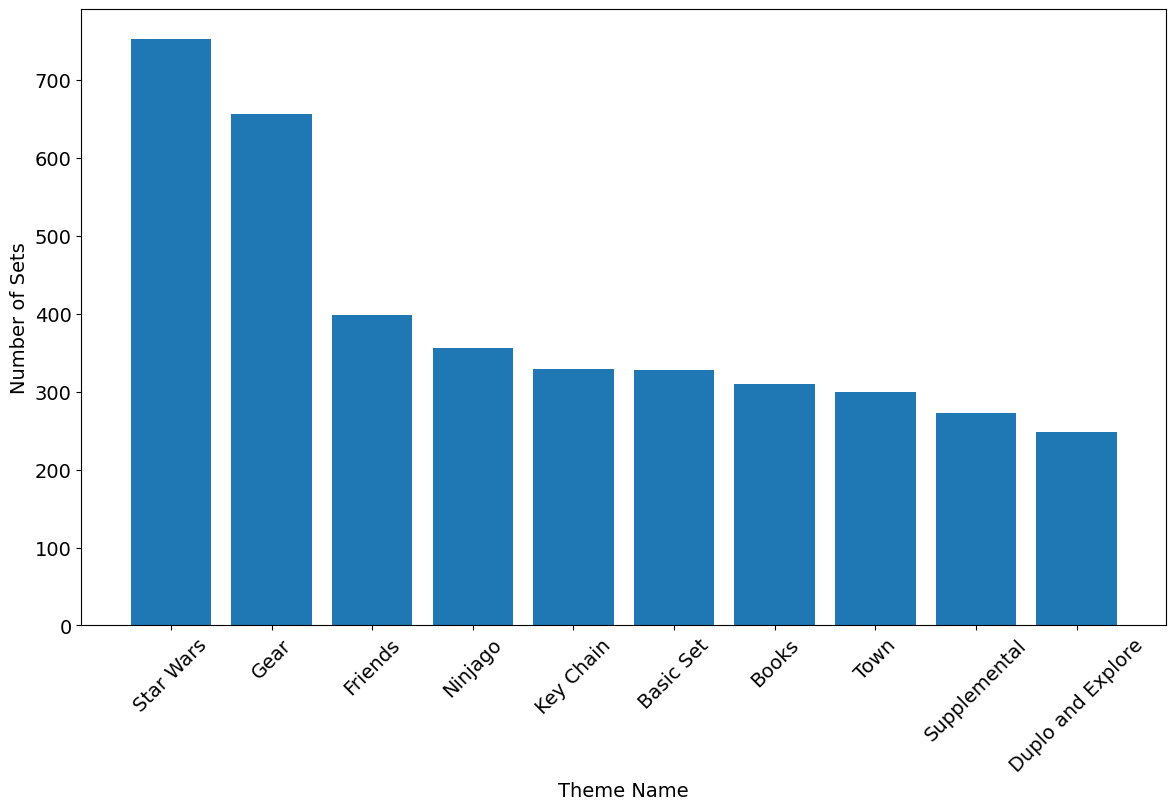

In [29]:
#now we can choose what size the chart is, add tick marks, and label our axes
plt.figure(figsize=(14,8))
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.ylabel('Number of Sets', fontsize=14)
plt.xlabel('Theme Name', fontsize=14)
#then reinitialize our table
plt.bar(merged_df.name[:10], merged_df.set_count[:10])

#Wow, they sell as many key chains as they do their basic sets!

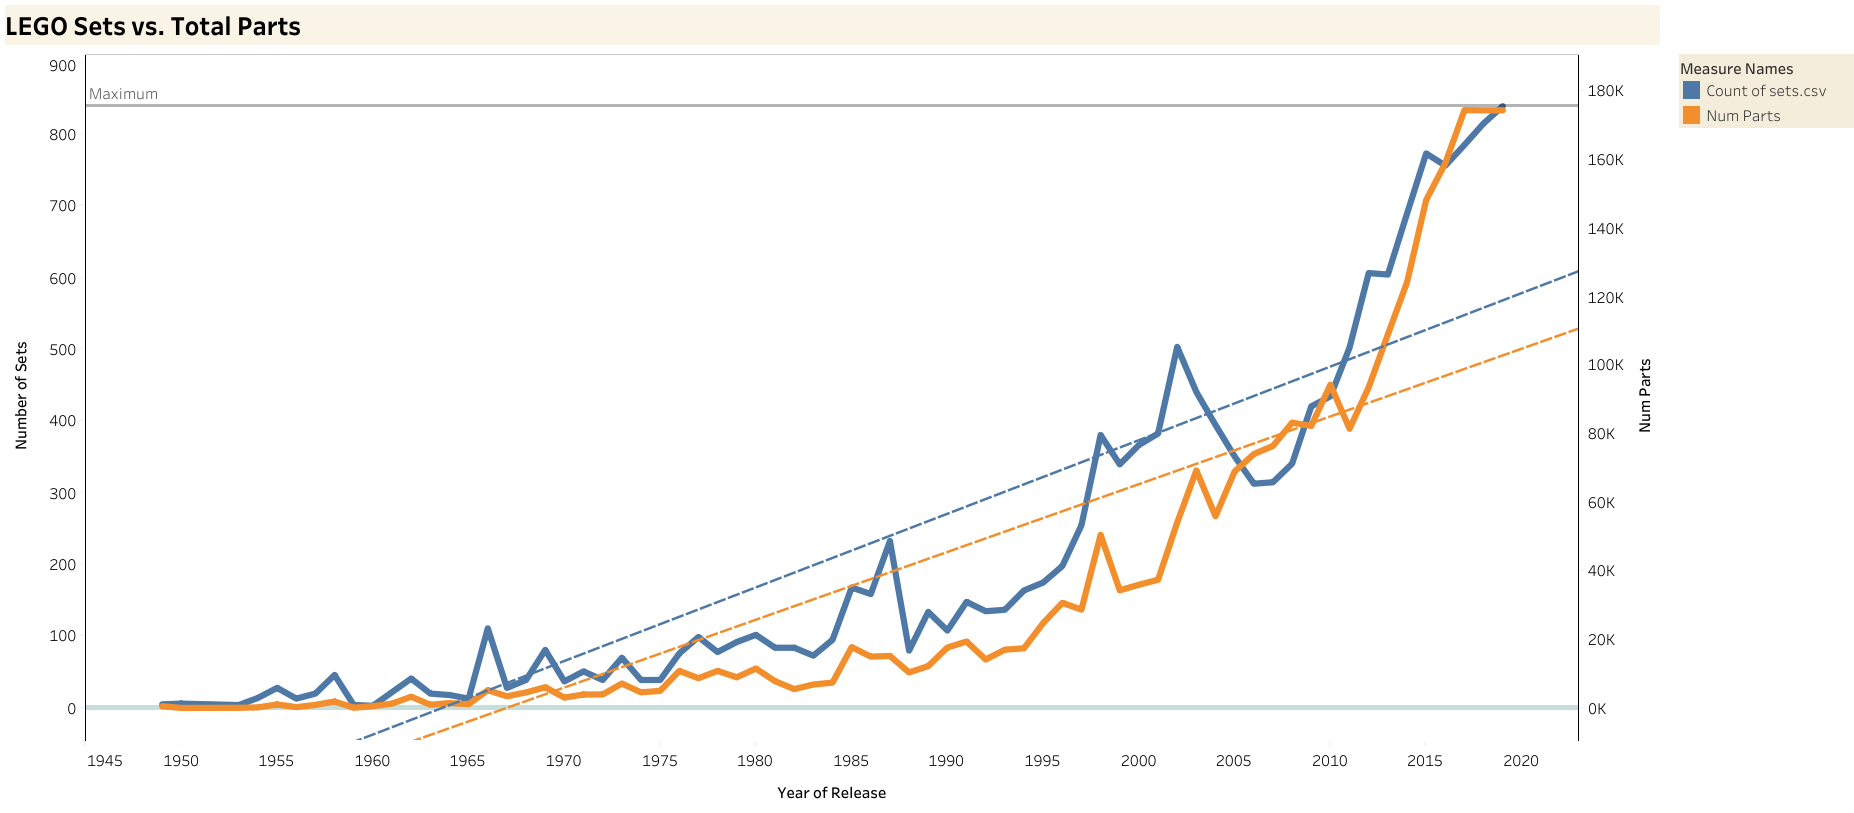

In [79]:
#so after the coursework was finished, I decided to take a look further into
#what exactly happened in the mid 00's, when they had that huge dip in sets

#so I took this opportunity to make a visualizer in Tableau for practice

data = Image.open('data/Lego00s.png')
data


<h1> Analysis </h1>
<h2> I was interested to see if the number of sets per year
was directly correlated to the number of total parts per year.<h2>

<h2> After doing some historical research, while there were still smaller sets, the 1980s saw the rise of more intricate models, especially within the Technic (Expert Builder) line. These sets might not have been produced in the same high volume as previous sets, potentially influencing the overall distribution of set numbers.
<br>
<h2> Seeking further, I discovered that in the mid 2000s,
Lego cancelled their work with many underperforming sets.
<br>
<h2>When comparing the number of parts, however, we see the business
plan in action.
<br>
<h2>Ditch lower performing sets, and produce more parts for
sets that were performing well and in 2010, set counts had climbed
back to where they would have been expected.